<a href="https://colab.research.google.com/github/Oldmanne13/face/blob/main/9face_bedre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Forberedelse og Forbindelse -  Tjek GPU

In [1]:
import tensorflow as tf
import os
from google.colab import drive

print("--- Trin 1: Forberedelse ---")

# Tjek GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print("❌ ADVARSEL: T4 GPU ikke fundet! Tjek Runtime-indstillinger.")
else:
    print("✅ Succes! T4 GPU er aktiv og klar.")

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("✅ Google Drive er monteret.")
else:
    print("ℹ️ Google Drive var allerede monteret.")

--- Trin 1: Forberedelse ---
✅ Succes! T4 GPU er aktiv og klar.
Mounted at /content/drive
✅ Google Drive er monteret.


Udpak data

In [2]:
print("--- Trin 2: Udpakning af billeder ---")

zip_path = '/content/drive/MyDrive/Facial_Expression_Project/archive (6).zip'
output_folder = '/content/local_data'

if os.path.exists(zip_path):
    print("📦 Pakker zip-fil ud... Vent venligst (dette kan tage mange minutter).")
    !unzip -q "{zip_path}" -d "{output_folder}"
    print(f"✅ Udpakning færdig! Filerne ligger nu i: {output_folder}")
else:
    print("❌ FEJL: Kunne ikke finde zip-filen på dit Drive. Tjek stien.")

--- Trin 2: Udpakning af billeder ---
📦 Pakker zip-fil ud... Vent venligst (dette kan tage mange minutter).
✅ Udpakning færdig! Filerne ligger nu i: /content/local_data


In [3]:
import os
import shutil
import yaml

print("--- Trin: Omorganiserer YOLO til TensorFlow format ---")

# 1. Hent klassenavnene fra din data.yaml
yaml_path = '/content/local_data/9 Facial Expressions you need/data.yaml'
with open(yaml_path, 'r') as f:
    data_info = yaml.safe_load(f)
    class_names = data_info['names']

print(f"Fundet 9 udtryk: {class_names}")

# 2. Funktion til at sortere billeder
def sort_yolo_to_folders(split):
    base = f'/content/local_data/9 Facial Expressions you need/{split}'
    img_dir = os.path.join(base, 'images')
    lbl_dir = os.path.join(base, 'labels')
    target_dir = f'/content/tf_data/{split}'

    for lbl_file in os.listdir(lbl_dir):
        if not lbl_file.endswith('.txt'): continue

        # Læs første tal i txt-filen (klassen)
        with open(os.path.join(lbl_dir, lbl_file), 'r') as f:
            first_line = f.readline().split()
            if not first_line: continue
            class_id = int(first_line[0])
            emotion_name = class_names[class_id]

        # Lav ny mappe: /content/tf_data/train/Happy/
        new_folder = os.path.join(target_dir, emotion_name)
        os.makedirs(new_folder, exist_ok=True)

        # Flyt billedet
        img_name = lbl_file.replace('.txt', '.jpg') # Eller .png
        src_img = os.path.join(img_dir, img_name)
        if os.path.exists(src_img):
            shutil.copy(src_img, os.path.join(new_folder, img_name))

# 3. Kør sorteringen for både train og valid
sort_yolo_to_folders('train')
sort_yolo_to_folders('valid')
print("✅ Færdig! Dine data er nu sorteret til TensorFlow.")

--- Trin: Omorganiserer YOLO til TensorFlow format ---
Fundet 9 udtryk: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'natural', 'sad', 'sleepy', 'surprised']
✅ Færdig! Dine data er nu sorteret til TensorFlow.


Indlæsning af Datasæt

In [4]:
print("--- Trin 3: Indlæser datasæt til TensorFlow ---")

# base_path = '/content/local_data/9 Facial Expressions you need'
# Din nye sti efter sorteringen
base_path = '/content/tf_data'

# Kør herefter din image_dataset_from_directory igen
# Nu vil den finde 9 klasser i stedet for 2!
# 1. Indlæs de rå datasæt først
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_path, 'train'),
    image_size=(64, 64),
    batch_size=32,
    label_mode='categorical'
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_path, 'valid'),
    image_size=(64, 64),
    batch_size=32,
    label_mode='categorical'
)

# 2. GEM klassenavnene nu, mens vi har adgang til dem!
class_names = raw_train_ds.class_names
print(f"✅ Klassenavne gemt: {class_names}")

# 3. Optimering (Her skifter objektet type til '_PrefetchDataset')
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = raw_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Datasæt er optimeret og klar til T4 GPU.")

--- Trin 3: Indlæser datasæt til TensorFlow ---
Found 64864 files belonging to 9 classes.
Found 1720 files belonging to 9 classes.
✅ Klassenavne gemt: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'natural', 'sad', 'sleepy', 'surprised']
✅ Datasæt er optimeret og klar til T4 GPU.


Design af AI-Modellen (CNN)
Dette er hjernen i projektet. Vi bruger et Convolutional Neural Network (CNN), som er standard i undervisningen til billeder.

In [5]:
print("--- Trin 4: Opbygger modellen ---")

# Vi bruger den variabel vi gemte i Trin 3 (class_names)
antal_klasser = len(class_names)

model = tf.keras.Sequential([
    # Ny måde at definere input på for at undgå 'UserWarning'
    tf.keras.layers.Input(shape=(64, 64, 3)),

    # Skalerer farver fra 0-255 til 0-1
    tf.keras.layers.Rescaling(1./255),

    # CNN lagene
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Klassificerings-lagene
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(antal_klasser, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"✅ Model er klar til at genkende {antal_klasser} ansigtsudtryk.")

--- Trin 4: Opbygger modellen ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,313 (6.20 MB)

 Trainable params: 1,626,313 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

✅ Model er klar til at genkende 9 ansigtsudtryk.


Træning

In [6]:
print("--- Trin 5: Starter træning ---")

# Vi starter med 10 runder (epochs)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

print("🎉 TRÆNING FÆRDIG!")

--- Trin 5: Starter træning ---
Epoch 1/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 210s 57ms/step - accuracy: 0.4698 - loss: 1.4353 - val_accuracy: 0.5465 - val_loss: 1.2647
Epoch 2/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6263 - loss: 1.0288 - val_accuracy: 0.6134 - val_loss: 1.0949
Epoch 3/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7239 - loss: 0.7731 - val_accuracy: 0.6453 - val_loss: 1.0454
Epoch 4/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7950 - loss: 0.5835 - val_accuracy: 0.6663 - val_loss: 1.0945
Epoch 5/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8489 - loss: 0.4332 - val_accuracy: 0.6651 - val_loss: 1.2650
Epoch 6/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8886 - loss: 0.3280 - val_accuracy: 0.6657 - val_loss: 1.3983
Epoch 7/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9142 - loss: 0.2553 - val_accuracy: 0.6645 - val_loss: 1.6107
Epoch 8/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms

--- Trin 6: Evaluerer træning med grafer ---


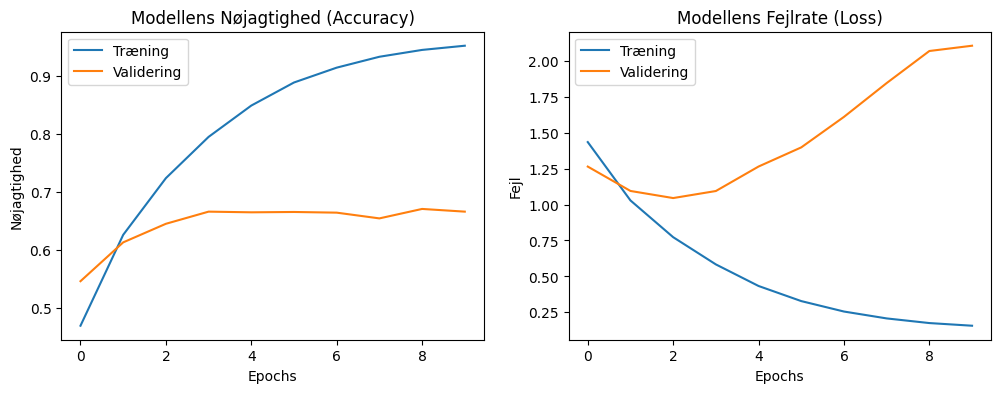

In [7]:
import matplotlib.pyplot as plt

print("--- Trin 6: Evaluerer træning med grafer ---")

# Lav en figur med to grafer ved siden af hinanden
plt.figure(figsize=(12, 4))

# Graf 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Træning')
plt.plot(history.history['val_accuracy'], label='Validering')
plt.title('Modellens Nøjagtighed (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Nøjagtighed')
plt.legend()

# Graf 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Træning')
plt.plot(history.history['val_loss'], label='Validering')
plt.title('Modellens Fejlrate (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Fejl')
plt.legend()

plt.show()

--- Trin 7: Test på et ukendt billede ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


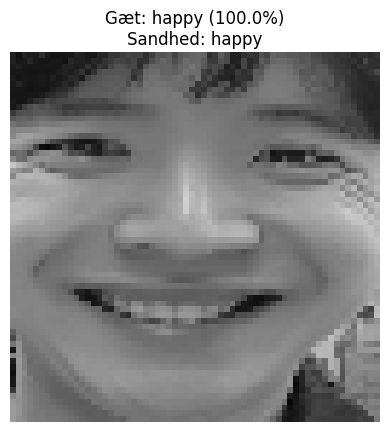

In [8]:
import numpy as np

print("--- Trin 7: Test på et ukendt billede ---")

# Vi tager et batch fra test-sættet (hvis du har defineret et, ellers brug val_ds)
# Her bruger vi val_ds som eksempel
for images, labels in val_ds.take(1):
    # Vælg det første billede i batchet
    img = images[0].numpy().astype("uint8")
    true_label = class_names[np.argmax(labels[0])]

    # Lad modellen gætte
    # Vi skal tilføje en ekstra dimension (batch dimension) med expand_dims
    prediction = model.predict(np.expand_dims(images[0], axis=0))
    predicted_label = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Vis billedet og resultatet
    plt.imshow(img)
    plt.title(f"Gæt: {predicted_label} ({confidence:.1f}%)\nSandhed: {true_label}")
    plt.axis("off")
    plt.show()